In [1]:
## Imports

import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [2]:
#!ls -l ./capstone-699-files

In [3]:
combine_unclean_df = pd.read_parquet("combined_weekly_dataset.parquet")

In [4]:
combine_unclean_df

,SHANGHAI_COMPOSITE,CVX,usd_index,GOLD_GLD,REAL_ESTATE_IYR,SLB,SILVER_SLV,CRUDE_OIL_USO,MATERIALS_XLB,ENERGY_XLE,...,HANG_SENG,NIKKEI_225,NASDAQ100,EURO_STOXX_50,VIX,TREASURY_10Y,TREASURY_2Y,NASDAQ100_QQQ,SP500_SPY,TREASURY_BOND_TLT
1995-01-06,NaN,7.065623,89.610001,NaN,NaN,6.349373,NaN,NaN,NaN,NaN,...,7683.299805,19519.460938,401.589996,NaN,13.130000,7.87,7.64,NaN,26.665779,NaN
1995-01-13,NaN,7.045661,88.139999,NaN,NaN,6.241495,NaN,NaN,NaN,NaN,...,7252.299805,19331.169922,410.480011,NaN,11.100000,7.69,7.39,NaN,27.063906,NaN
1995-01-20,NaN,7.384977,87.449997,NaN,NaN,6.549716,NaN,NaN,NaN,NaN,...,7278.100098,18840.220703,410.130005,NaN,12.150000,7.82,7.50,NaN,26.955322,NaN
1995-01-27,NaN,7.384977,87.620003,NaN,NaN,6.673009,NaN,NaN,NaN,NaN,...,7297.100098,18104.349609,407.220001,NaN,11.250000,7.66,7.29,NaN,27.281069,NaN
1995-02-03,NaN,7.305134,88.190002,NaN,NaN,6.642181,NaN,NaN,NaN,NaN,...,7478.899902,18538.970703,416.140015,NaN,10.980000,7.49,7.14,NaN,27.814920,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27,4162.880859,186.759995,97.610001,483.750000,100.996521,51.340000,84.989998,81.949997,53.173531,55.557003,...,26630.539062,58850.269531,24960.039062,6138.410156,19.860001,3.97,3.38,606.525208,684.121643,90.518997
2026-03-06,4124.193848,189.940002,98.989998,473.510010,98.742844,46.900002,75.940002,108.769997,49.639248,56.202785,...,25757.289062,55620.839844,24643.019531,5719.899902,29.490000,4.15,3.56,598.994690,670.548706,88.459999
2026-03-13,4095.447998,196.820007,100.360001,460.839996,97.227097,44.720001,72.690002,119.889999,48.972214,57.325451,...,25465.599609,53819.609375,24380.730469,5716.609863,27.190001,4.28,3.73,592.972290,660.486206,86.540001
2026-03-20,3957.052979,201.729996,99.650002,413.380005,93.188431,46.630001,61.520000,121.430000,46.771999,58.925003,...,25277.320312,53372.531250,23898.150391,5501.279785,26.780001,4.39,3.88,581.326965,648.570007,85.830002


This will be the first step by logging the different, dropping na, then start rolling window of 4, and 12

Going to test some theories, unsure whether it works out but just brain storming below

In [5]:
df = combine_unclean_df.copy()

# dates already in index
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[~df.index.isna()].copy()
df = df.sort_index()

# remove duplicate columns / dates
df = df.loc[:, ~df.columns.duplicated()].copy()
df = df[~df.index.duplicated(keep="first")].copy()

price_cols = [
    "SP500_SPY",
    "NASDAQ100_QQQ",
    "DOW_JONES",
    "NASDAQ100",
    "NIKKEI_225",
    "SHANGHAI_COMPOSITE",
    "HANG_SENG",
    "TREASURY_BOND_TLT",
    "GOLD_GLD",
    "usd_index"
]

# weekly log returns
log_returns = np.log(df[price_cols] / df[price_cols].shift(1))
log_returns = log_returns.dropna(how="all")

# rolling vol
volatility_4w = log_returns.rolling(window=4, min_periods=4).std()
volatility_12w = log_returns.rolling(window=12, min_periods=12).std()

# vol of vol
vov_4w = volatility_4w.rolling(window=4, min_periods=4).std()
vov_12w = volatility_12w.rolling(window=12, min_periods=12).std()

# aggregate regime features
global_vol_4w = volatility_4w.mean(axis=1)
global_vol_12w = volatility_12w.mean(axis=1)
vol_slope = global_vol_4w - global_vol_12w
global_vov_12w = vov_12w.mean(axis=1)

# macro features
yield_curve = df["TREASURY_10Y"] - df["TREASURY_2Y"]
vix_levels = df["VIX"]

# final feature set
features = pd.DataFrame({
    "global_vol": global_vol_12w,
    "vol_slope": vol_slope,
    "vov": global_vov_12w,
    "yield_slope": yield_curve,
    "vix": vix_levels
}, index=df.index)

features = pd.concat([features, log_returns.add_suffix("_ret")], axis=1)
features = features.dropna()

In [6]:
features.describe()

,global_vol,vol_slope,vov,yield_slope,vix,SP500_SPY_ret,NASDAQ100_QQQ_ret,DOW_JONES_ret,NASDAQ100_ret,NIKKEI_225_ret,SHANGHAI_COMPOSITE_ret,HANG_SENG_ret,TREASURY_BOND_TLT_ret,GOLD_GLD_ret,usd_index_ret
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000
mean,0.022215,-0.001377,0.003519,0.985161,18.923393,0.002156,0.002772,0.001553,0.002652,0.001664,0.000920,0.000671,0.000811,0.001965,0.000065
std,0.008541,0.006225,0.002439,0.944630,8.483390,0.023601,0.026920,0.023040,0.026968,0.028392,0.030786,0.029132,0.019146,0.023831,0.010469
min,0.010575,-0.035599,0.000885,-1.060000,9.140000,-0.157189,-0.119357,-0.189978,-0.133755,-0.174281,-0.148979,-0.142726,-0.080053,-0.108684,-0.044244
25%,0.016822,-0.004480,0.002269,0.212500,13.265000,-0.009028,-0.011963,-0.009223,-0.011958,-0.013712,-0.014936,-0.017878,-0.010257,-0.011183,-0.006266
50%,0.020215,-0.001020,0.002950,0.890000,16.495000,0.003552,0.003912,0.002918,0.003816,0.002577,0.002114,0.002623,0.001562,0.003338,0.000344
75%,0.025845,0.001764,0.003782,1.687500,21.970000,0.014764,0.018785,0.013602,0.018808,0.018096,0.017710,0.019206,0.012155,0.016527,0.006284
max,0.072380,0.038117,0.019489,2.910000,79.129997,0.124801,0.108439,0.120840,0.104555,0.158171,0.139447,0.122223,0.084353,0.129320,0.047744


In [10]:
#REVISED

#Pick variables used to detect regimes
#Find returns for major assets
#Find market volatility
#Find momentum
#Find VIX changes
#Find yield spread (10Y − 2Y)
#Create final feature dataset for clustering
#Exclude TLT and GLD so the clustering sample starts earlier

combine2 = pd.read_parquet("data_prep.parquet")

rdf2 = combine2[["SPY", "QQQ", "VIX", "10_Year_Treasury_Yield", "2_Year_Treasury_Yield"]].copy()
rdf2 = rdf2.rename(columns={"10_Year_Treasury_Yield": "TREASURY_10Y","2_Year_Treasury_Yield": "TREASURY_2Y"})
rdf2["SPY_return"] = rdf2["SPY"].pct_change()
rdf2["QQQ_return"] = rdf2["QQQ"].pct_change()
rdf2["SPY_vol_12"] = rdf2["SPY_return"].rolling(12).std()
rdf2["SPY_vol_4"] = rdf2["SPY_return"].rolling(4).std()
rdf2["SPY_momentum_12"] = rdf2["SPY"].pct_change(12)
rdf2["VIX_change"] = rdf2["VIX"].pct_change()
rdf2["yield_spread"] = rdf2["TREASURY_10Y"] - rdf2["TREASURY_2Y"]
fcol2 = ["SPY_return","QQQ_return","SPY_vol_12","SPY_vol_4","SPY_momentum_12","VIX","VIX_change","TREASURY_10Y",
        "TREASURY_2Y", "yield_spread"]

kmf2 = rdf2[fcol2].dropna().copy()

kmf2.to_parquet("reg_feat2.parquet")
rdf2.to_parquet("reg_base2.parquet")

In [11]:
merged_features = features.join(kmf2, how = 'inner')
merged_features = merged_features.drop(columns=["vix", "yield_slope"], errors="ignore")

merged_features.index = pd.to_datetime(merged_features.index)
merged_features = merged_features.sort_index()
merged_features.index.name = "date"

In [14]:
merged_features.to_csv("Features_volatility.csv")

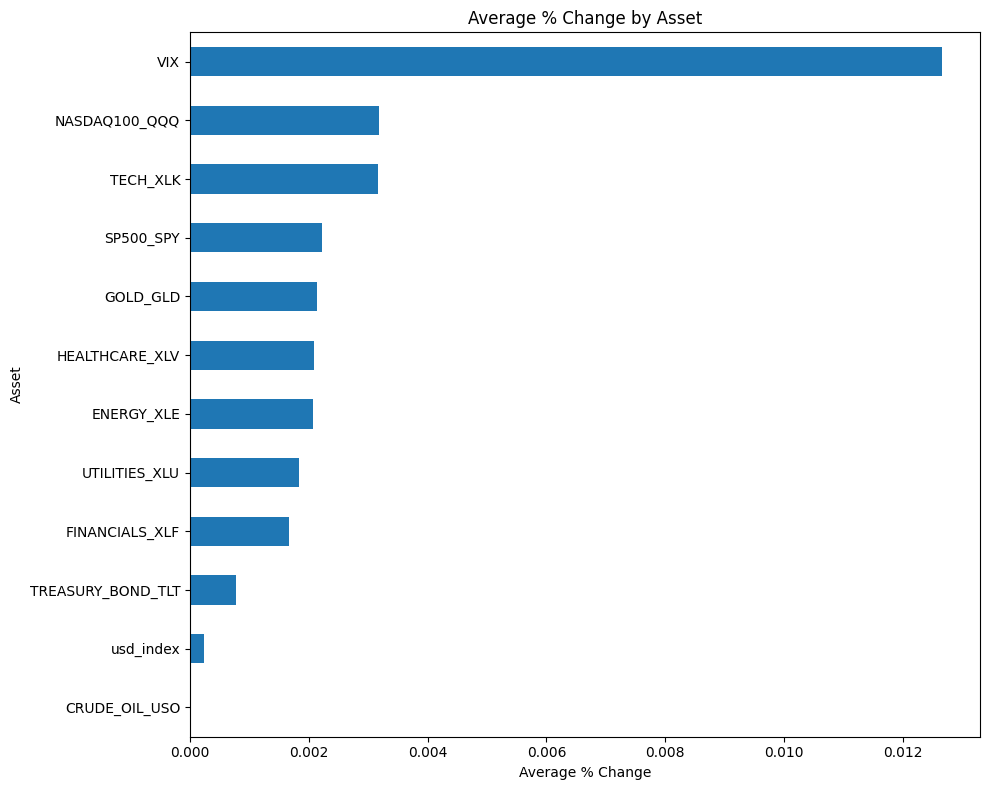

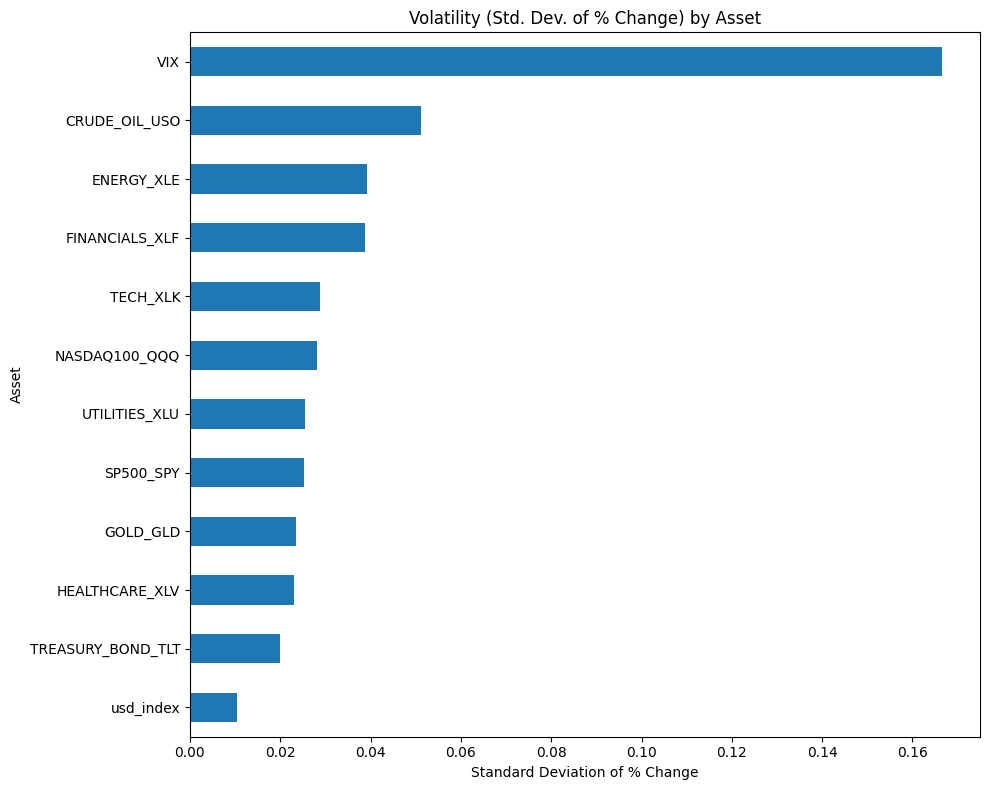

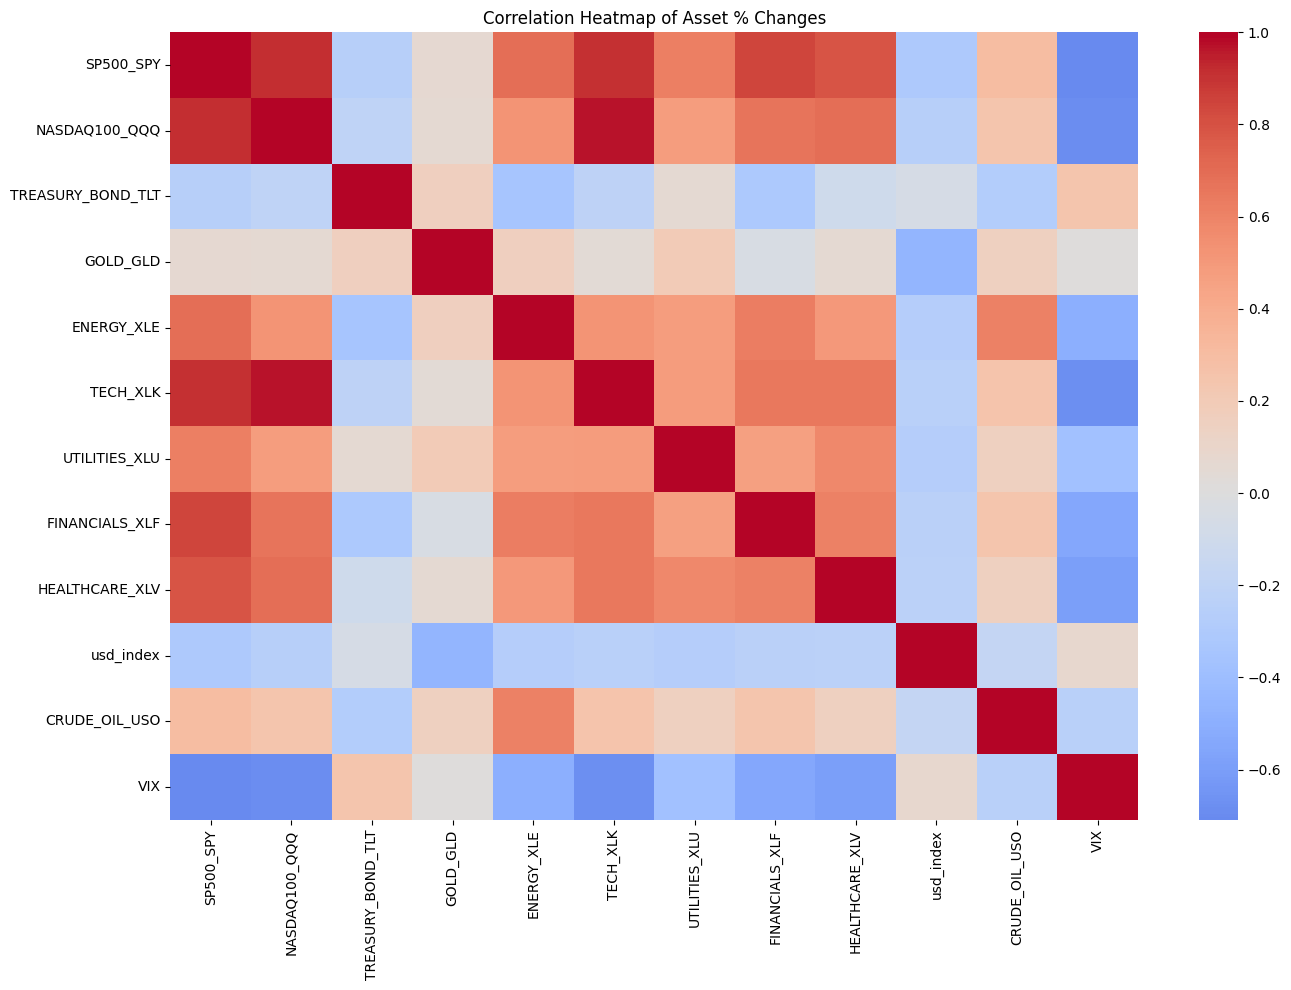

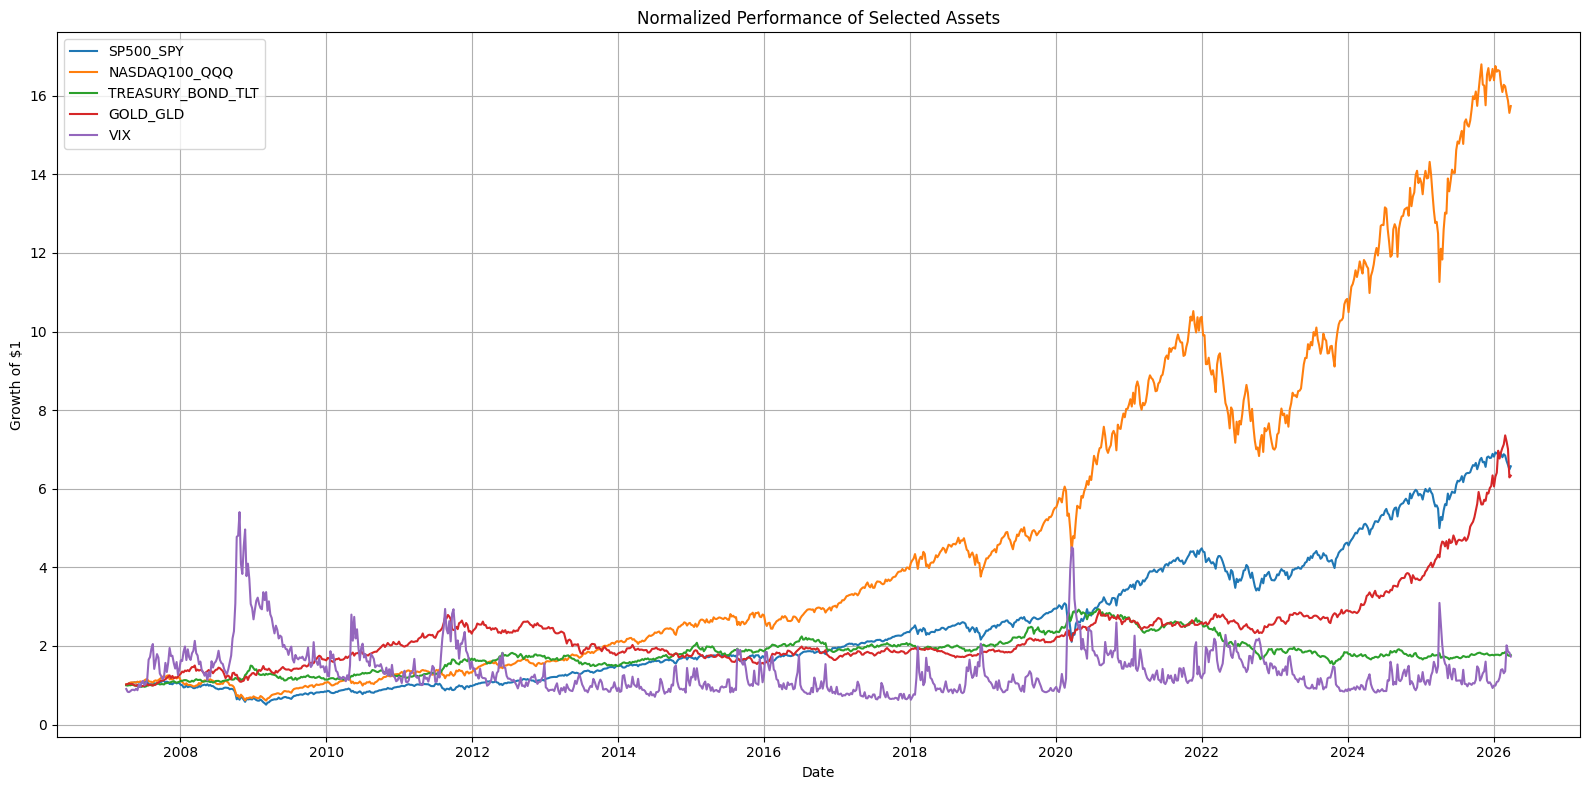

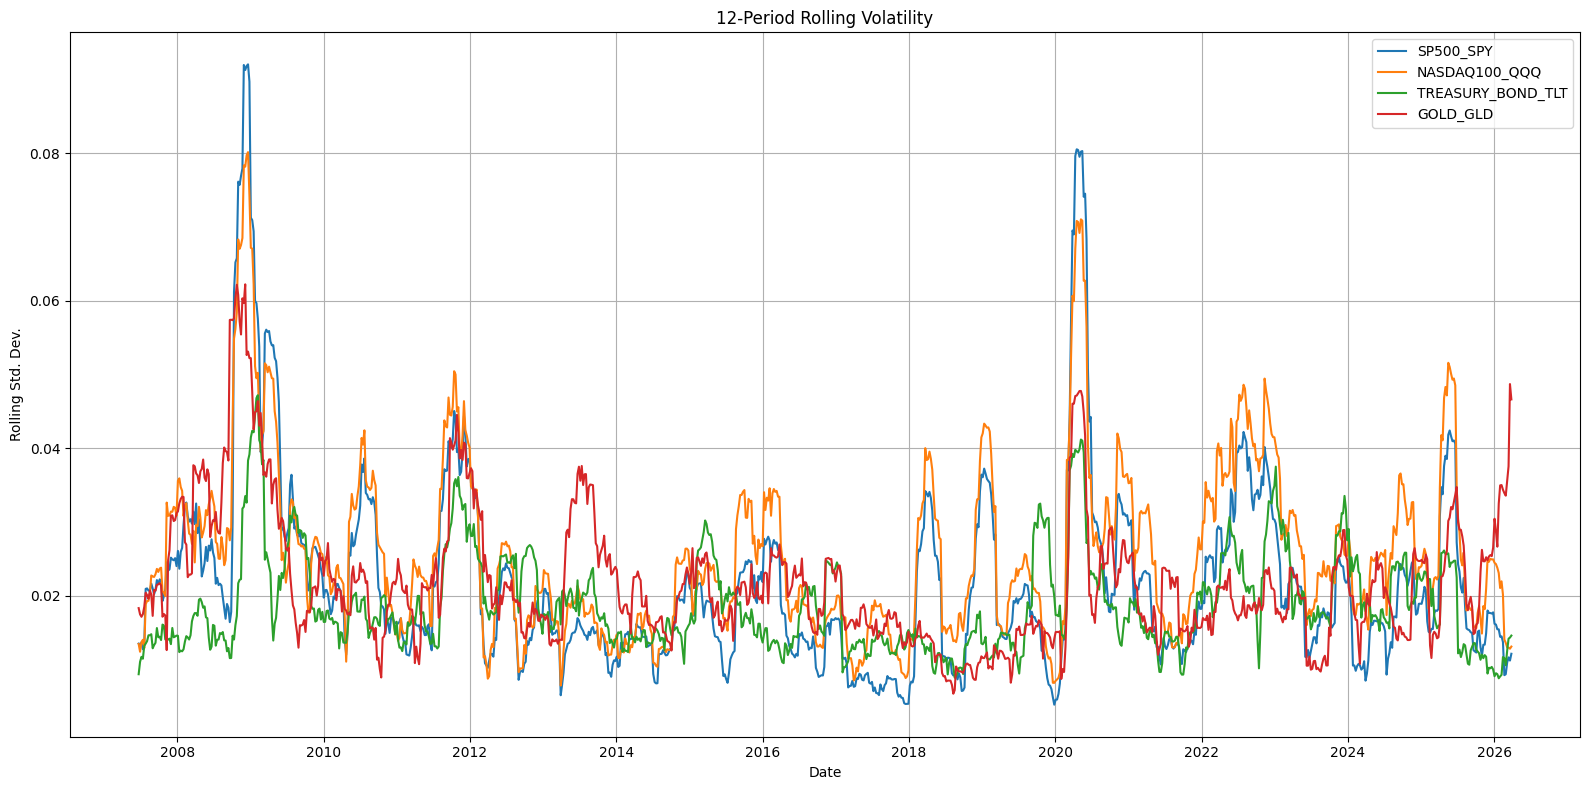

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. copy original df
df = combine_unclean_df.copy()

# 2. convert to % returns
returns_df = df.pct_change()
returns_df = returns_df.replace([np.inf, -np.inf], np.nan)
returns_df = returns_df.dropna()

# 3. cleaner subset for visuals
selected_assets = [
    "SP500_SPY",
    "NASDAQ100_QQQ",
    "TREASURY_BOND_TLT",
    "GOLD_GLD",
    "ENERGY_XLE",
    "TECH_XLK",
    "UTILITIES_XLU",
    "FINANCIALS_XLF",
    "HEALTHCARE_XLV",
    "usd_index",
    "CRUDE_OIL_USO",
    "VIX"
]

returns_selected = returns_df[selected_assets]

# VISUAL 1: Average Return
avg_returns = returns_selected.mean().sort_values()

plt.figure(figsize=(10, 8))
avg_returns.plot(kind='barh')
plt.title("Average % Change by Asset")
plt.xlabel("Average % Change")
plt.ylabel("Asset")
plt.tight_layout()
plt.show()

# VISUAL 2: Volatility
volatility = returns_selected.std().sort_values()

plt.figure(figsize=(10, 8))
volatility.plot(kind='barh')
plt.title("Volatility (Std. Dev. of % Change) by Asset")
plt.xlabel("Standard Deviation of % Change")
plt.ylabel("Asset")
plt.tight_layout()
plt.show()

# VISUAL 3: Correlation Heatmap
corr_matrix = returns_selected.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Asset % Changes")
plt.tight_layout()
plt.show()

# VISUAL 4: Growth of $1
normalized_df = (1 + returns_selected).cumprod()

plt.figure(figsize=(16, 8))
for col in ["SP500_SPY", "NASDAQ100_QQQ", "TREASURY_BOND_TLT", "GOLD_GLD", "VIX"]:
    if col in normalized_df.columns:
        plt.plot(normalized_df.index, normalized_df[col], label=col)

plt.title("Normalized Performance of Selected Assets")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# VISUAL 5: Rolling Volatility
rolling_vol = returns_selected[["SP500_SPY", "NASDAQ100_QQQ", "TREASURY_BOND_TLT", "GOLD_GLD"]].rolling(12).std()

plt.figure(figsize=(16, 8))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)

plt.title("12-Period Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std. Dev.")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>